In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv(
    "../data/processed/multilingual_sentiment_cleaned.csv"
)

df.head()

,text,sentiment,language,cleaned_text
0,"Next date - Birmingham, The Rainbow, Sun 7th J...",Positive,English,next date birmingham the rainbow sun th june s...
1,Action king dialogue semma..... avanoda sindh...,Positive,Tamil,action king dialogue semma avanoda sindhanayum...
2,"Appedilaam nadekaathu, nadake kudaathu!! The ...",Positive,Tamil,appedilaam nadekaathu nadake kudaathu the bull...
3,Looks like d Mixture of Kaala+Kabali..... ...,Positive,Tamil,looks like d mixture of kaalakabali sure antho...
4,Nfg greatest hits cd cracked,Negative,English,nfg greatest hits cd cracked


In [3]:
df["label"] = df["sentiment"].map({
    "Negative": 0,
    "Positive": 1
})

In [4]:
X = df["cleaned_text"]

y = df["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

Model 1 — Logistic Regression

In [7]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr.predict(
    X_test_tfidf
)

In [8]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1:",
      f1_score(y_test, lr_pred))

Accuracy: 0.7908031088082902
Precision: 0.8025335320417287
Recall: 0.8666845493562232
F1: 0.8333763218983751


In [9]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.77      0.68      0.72      2448
           1       0.80      0.87      0.83      3728

    accuracy                           0.79      6176
   macro avg       0.79      0.77      0.78      6176
weighted avg       0.79      0.79      0.79      6176



In [10]:
print(
    confusion_matrix(
        y_test,
        lr_pred
    )
)

[[1653  795]
 [ 497 3231]]


Model 2 — Multinomial Naive Bayes

In [12]:
nb = MultinomialNB()

nb.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb.predict(
    X_test_tfidf
)

In [13]:
print("Accuracy:",
      accuracy_score(y_test, nb_pred))

print("Precision:",
      precision_score(y_test, nb_pred))

print("Recall:",
      recall_score(y_test, nb_pred))

print("F1:",
      f1_score(y_test, nb_pred))

Accuracy: 0.7786593264248705
Precision: 0.834135295782621
Recall: 0.7905042918454935
F1: 0.8117339209475279


Model 3 — Linear SVM

In [14]:
svm = LinearSVC(
    random_state=42
)

svm.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm.predict(
    X_test_tfidf
)

In [15]:
print("Accuracy:",
      accuracy_score(y_test, svm_pred))

print("Precision:",
      precision_score(y_test, svm_pred))

print("Recall:",
      recall_score(y_test, svm_pred))

print("F1:",
      f1_score(y_test, svm_pred))

Accuracy: 0.7702396373056994
Precision: 0.7994811932555124
Recall: 0.8267167381974249
F1: 0.8128708954239747


Model Comparison Table

In [16]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, nb_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, nb_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, svm_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.790803,0.802534,0.866685,0.833376
1,Naive Bayes,0.778659,0.834135,0.790504,0.811734
2,Linear SVM,0.770240,0.799481,0.826717,0.812871


In [17]:
results.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

In [18]:
import joblib

joblib.dump(
    lr,
    "../models/logistic_regression_model.pkl"
)

print("Best model saved successfully")

Best model saved successfully


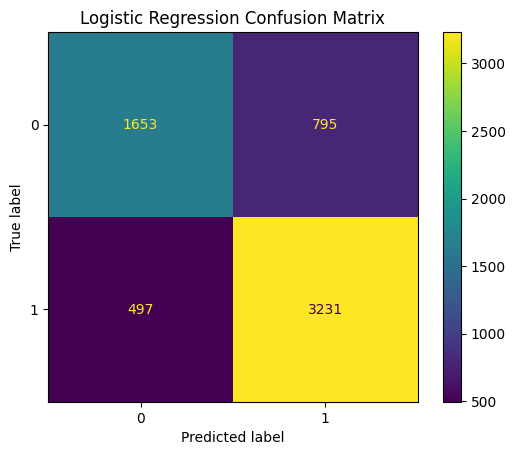

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

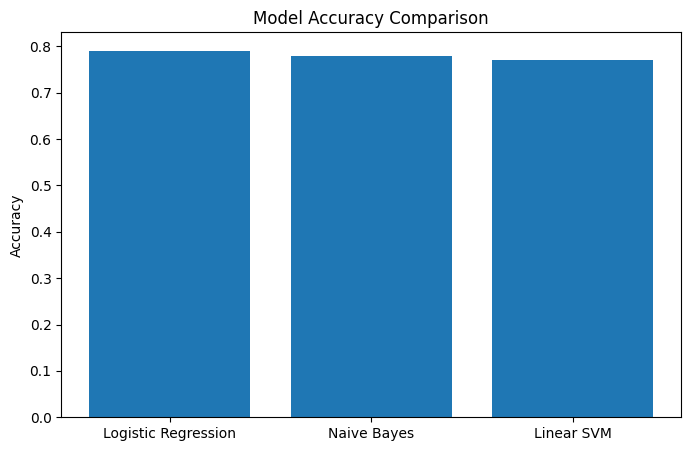

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

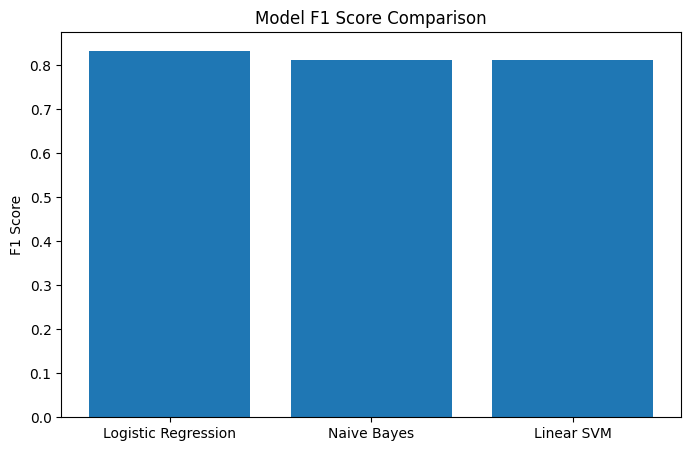

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")

plt.show()

MODEL TRAINING SUMMARY

Models Evaluated:
1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear SVM

Best Model:
Logistic Regression

Accuracy:
79.08%

Precision:
80.25%

Recall:
86.67%

F1 Score:
83.34%

Model Saved:
models/logistic_regression_model.pkl